In [1]:
import torch

# Check CUDA availability
cuda_available = torch.cuda.is_available()

print("CUDA Available:", cuda_available)

# Set device
device = torch.device(
    "cuda" if cuda_available else "cpu"
)

print("Using device:", device)

# If GPU exists, print GPU details
if cuda_available:

    print("GPU Name:",
          torch.cuda.get_device_name(0))

    print("CUDA Version:",
          torch.version.cuda)

CUDA Available: True
Using device: cuda
GPU Name: Tesla T4
CUDA Version: 12.8


In [2]:
# Install required libraries

!pip install -q \
face_recognition \
timm \
seaborn \
scikit-learn \
opencv-python \
matplotlib \
pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 18.6 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [5]:
# ==========================================
# CHECK CORRUPTED VIDEOS
# ==========================================

import glob
import torch
import torchvision
from torchvision import transforms
import os
import numpy as np
import cv2

# ------------------------------------------
# FRAME EXTRACTION FUNCTION
# ------------------------------------------

def frame_extract(path):

    vidObj = cv2.VideoCapture(path)

    success = True

    while success:

        success, image = vidObj.read()

        if success:

            # Convert BGR → RGB
            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )

            yield image

    vidObj.release()


# ------------------------------------------
# VALIDATE VIDEO FUNCTION
# ------------------------------------------

def validate_video(video_path, transform):

    count = 20
    frames = []

    cap = cv2.VideoCapture(video_path)

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    # Skip very short videos
    if total_frames < count:

        cap.release()

        raise Exception(
            "Too few frames"
        )

    # Uniform frame sampling
    frame_ids = np.linspace(
        0,
        total_frames - 1,
        count,
        dtype=int
    )

    for fid in frame_ids:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            fid
        )

        success, frame = cap.read()

        if not success:

            cap.release()

            raise Exception(
                "Frame read failed"
            )

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frame = transform(frame)

        frames.append(frame)

    cap.release()

    frames = torch.stack(frames)

    return frames


# ------------------------------------------
# TRANSFORMS
# ------------------------------------------

im_size = 112

mean = [0.485, 0.456, 0.406]

std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize(
        (im_size, im_size)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean,
        std
    )

])


# ------------------------------------------
# LOAD VIDEO FILES
# ------------------------------------------

video_fil = glob.glob(
    '/kaggle/input/datasets/lalithaboyala/datasett/Face_only_data/*.mp4'
)

print(
    "Total no of videos:",
    len(video_fil)
)


# ------------------------------------------
# VALIDATE ALL VIDEOS
# ------------------------------------------

count = 0

corrupted_videos = []

for video in video_fil:

    try:

        validate_video(
            video,
            train_transforms
        )

        count += 1

    except Exception as e:

        corrupted_videos.append(video)

        print(
            "Corrupted video:",
            video
        )

print(
    "\nValid videos:",
    count
)

print(
    "Corrupted videos:",
    len(corrupted_videos)
)

Total no of videos: 3846

Valid videos: 3846
Corrupted videos: 0


In [ ]:
import shutil
import os

# Destination folder
corrupted_folder = "/kaggle/working/corrupted_videos"

# Create folder if not exists
os.makedirs(corrupted_folder, exist_ok=True)

# Move corrupted videos
for vid in corrupted_videos:

    try:
        filename = os.path.basename(vid)

        destination = os.path.join(
            corrupted_folder,
            filename
        )

        shutil.move(vid, destination)

        print("Moved:", filename)

    except Exception as e:

        print("Failed to move:", vid)

In [6]:
# ==========================================
# LOAD PREPROCESSED VIDEOS
# ==========================================

import glob
import numpy as np
import cv2
import random

# Load video paths

video_files = glob.glob(
    '/kaggle/input/datasets/lalithaboyala/datasett/Face_only_data/*.mp4'
)

# Shuffle once
random.shuffle(video_files)

valid_video_files = []
frame_count = []

MIN_FRAMES = 100

# ------------------------------------------
# CHECK FRAME COUNT SAFELY
# ------------------------------------------

for video_file in video_files:

    cap = cv2.VideoCapture(video_file)

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    cap.release()

    if total_frames >= MIN_FRAMES and total_frames > 0:

        valid_video_files.append(video_file)

        frame_count.append(total_frames)

# Replace old list safely
video_files = valid_video_files

# ------------------------------------------
# PRINT STATS
# ------------------------------------------

print("Total valid videos:", len(video_files))

print(
    "Average frame per video:",
    np.mean(frame_count)
)

print(
    "Minimum frames:",
    np.min(frame_count)
)

print(
    "Maximum frames:",
    np.max(frame_count)
)

Total valid videos: 3844
Average frame per video: 147.945889698231
Minimum frames: 123
Maximum frames: 148


In [7]:
# ==========================================
# VIDEO DATASET
# ==========================================

import torch
from torch.utils.data.dataset import Dataset
import os
import numpy as np
import cv2

class video_dataset(Dataset):

    def __init__(
        self,
        video_names,
        labels,
        sequence_length=10,
        transform=None
    ):

        self.video_names = video_names
        self.transform = transform
        self.count = sequence_length

        # ----------------------------------
        # FAST LABEL LOOKUP
        # ----------------------------------

        self.label_dict = dict(
            zip(
                labels["File Path"],
                labels["Label"]
            )
        )

    def __len__(self):

        return len(self.video_names)

    def __getitem__(self, idx):

        video_path = self.video_names[idx]

        video_name = os.path.basename(video_path)

        # ----------------------------------
        # FAST LABEL FETCH
        # ----------------------------------

        label = self.label_dict[video_name]

        label = 1 if label == "REAL" else 0

        frames = self.sample_frames(video_path)

        return frames, label


    # ==========================================
    # UNIFORM FRAME SAMPLING
    # ==========================================

    def sample_frames(self, video_path):

        cap = cv2.VideoCapture(video_path)

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        frame_ids = np.linspace(
            0,
            total_frames - 1,
            self.count,
            dtype=int
        )

        frames = []

        for fid in frame_ids:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                fid
            )

            success, frame = cap.read()

            if success:

                # BGR → RGB
                frame = cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )

                if self.transform:

                    frame = self.transform(frame)

                frames.append(frame)

        cap.release()

        # ----------------------------------
        # HANDLE MISSING FRAMES
        # ----------------------------------

        if len(frames) == 0:

            raise RuntimeError(
                f"Empty video: {video_path}"
            )

        while len(frames) < self.count:

            frames.append(frames[-1])

        frames = torch.stack(frames)

        return frames


# ==========================================
# IMAGE PLOT FUNCTION
# ==========================================

import matplotlib.pyplot as plt

def im_plot(tensor):

    image = tensor.cpu().numpy().transpose(1,2,0)

    b,g,r = cv2.split(image)

    image = cv2.merge((r,g,b))

    image = image*[0.22803, 0.22145, 0.216989] + \
            [0.43216, 0.394666, 0.37645]

    image = image*255.0

    plt.imshow(image.astype(int))

    plt.axis("off")

    plt.show()

In [8]:
# ==========================================
# COUNT REAL AND FAKE VIDEOS 
# ==========================================

def number_of_real_and_fake_videos(
        data_list,
        labels):

    fake = 0
    real = 0

    # Fast lookup dictionary
    label_dict = dict(
        zip(
            labels["File Path"],
            labels["Label"]
        )
    )

    for video_path in data_list:

        video_name = os.path.basename(video_path)

        label = label_dict.get(video_name)

        if label == "FAKE":
            fake += 1

        elif label == "REAL":
            real += 1

    return real, fake

Train: 3075
Validation: 769
TRAIN: Real: 1501 Fake: 1574
VALID: Real: 378 Fake: 391


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-21..225].


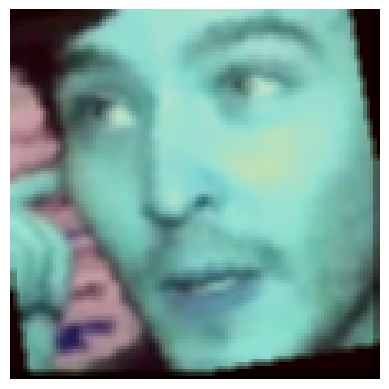

In [9]:
# ==========================================
# REQUIRED IMPORTS
# ==========================================

import torch

from torch.utils.data import DataLoader

from torchvision import transforms

import random
import pandas as pd


# ==========================================
# LOAD LABELS
# ==========================================

header_list = ["File Path","Label"]

labels = pd.read_csv(
    '/kaggle/input/datasets/lalithaboyala/csv-file/dataset_labels.csv',
    names=header_list
)


# ==========================================
# SPLIT DATA
# ==========================================

train_videos = video_files[:int(0.8*len(video_files))]

valid_videos = video_files[int(0.8*len(video_files)):]

print("Train:", len(train_videos))

print("Validation:", len(valid_videos))


# ==========================================
# COUNT REAL / FAKE
# ==========================================

train_real, train_fake = number_of_real_and_fake_videos(
    train_videos,
    labels
)

val_real, val_fake = number_of_real_and_fake_videos(
    valid_videos,
    labels
)

print("TRAIN: Real:", train_real, "Fake:", train_fake)

print("VALID: Real:", val_real, "Fake:", val_fake)


# ==========================================
# TRANSFORMS
# ==========================================

im_size = 112

train_transforms = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((im_size,im_size)),

    # 🔴 DATA AUGMENTATION

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05),
        scale=(0.95,1.05)
    ),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1,2.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )

])


# Validation Transform (NO augmentation)

test_transforms = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((im_size,im_size)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )

])


# ==========================================
# CREATE DATASETS
# ==========================================

train_data = video_dataset(

    train_videos,

    labels,

    sequence_length=10,   # ⭐ improved

    transform=train_transforms

)

val_data = video_dataset(

    valid_videos,

    labels,

    sequence_length=10,   # ⭐ improved

    transform=test_transforms   # ⭐ FIXED

)


# ==========================================
# CREATE DATALOADERS
# ==========================================

train_loader = DataLoader(

    train_data,

    batch_size=2,   # increase if GPU allows

    shuffle=True,

    num_workers=2,

    pin_memory=True

)

valid_loader = DataLoader(

    val_data,

    batch_size=2,

    shuffle=False,   # ⭐ FIXED

    num_workers=2,

    pin_memory=True

)


# ==========================================
# TEST SAMPLE
# ==========================================

image,label = train_data[0]

im_plot(image[0,:,:,:])

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import timm

class HybridDeepfakeModel(nn.Module):

    def __init__(
        self,
        num_classes=2,
        seq_len=10
    ):

        super().__init__()

        self.seq_len = seq_len

        # ===================================
        # Vision Transformer
        # ===================================

        self.vit = timm.create_model(

            'vit_small_patch16_224',

            pretrained=True,

            num_classes=0

        )

        self.vit_proj = nn.Linear(

            384,

            512

        )

        # ===================================
        # CNN Backbone
        # ===================================

        resnet = models.resnet50(

            weights=models.ResNet50_Weights.DEFAULT

        )

        self.cnn = nn.Sequential(

            *list(resnet.children())[:-2]

        )

        self.avgpool = nn.AdaptiveAvgPool2d(1)

        # ===================================
        # LSTM
        # ===================================

        self.lstm = nn.LSTM(

            input_size=2048,

            hidden_size=512,

            num_layers=1,

            batch_first=True

        )

        # ===================================
        # FAST FREQUENCY BRANCH (FFT)
        # ===================================

        self.freq_cnn = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)

        )

        self.freq_fc = nn.Linear(

            128,

            256

        )

        # ===================================
        # Fusion Layer
        # ===================================

        self.fc1 = nn.Linear(

            512 + 512 + 256,

            512

        )

        self.dropout = nn.Dropout(0.4)

        self.fc2 = nn.Linear(

            512,

            num_classes

        )

    # ===================================
    # FAST GPU FFT
    # ===================================

    def compute_frequency(self, x):

        # RGB → grayscale

        x = x.mean(

            dim=1,

            keepdim=True

        )

        # GPU FFT

        fft = torch.fft.fft2(x)

        fft = torch.abs(fft)

        return fft

    # ===================================
    # FORWARD
    # ===================================

    def forward(self, x):

        batch, seq, c, h, w = x.shape

        x_cnn = x.view(

            batch*seq,

            c,

            h,

            w

        )

        # -----------------------------------
        # CNN + LSTM
        # -----------------------------------

        feat = self.cnn(x_cnn)

        feat = self.avgpool(feat)

        feat = feat.view(

            batch,

            seq,

            2048

        )

        lstm_out,_ = self.lstm(feat)

        temporal_feat = torch.mean(

            lstm_out,

            dim=1

        )

        # -----------------------------------
        # ViT
        # -----------------------------------

        vit_in = F.interpolate(

            x_cnn,

            size=(224,224)

        )

        vit_feat = self.vit(vit_in)

        vit_feat = self.vit_proj(vit_feat)

        vit_feat = vit_feat.view(

            batch,

            seq,

            512

        )

        vit_feat = torch.mean(

            vit_feat,

            dim=1

        )

        # -----------------------------------
        # Frequency Branch
        # -----------------------------------

        freq_input = self.compute_frequency(x_cnn)

        freq_feat = self.freq_cnn(freq_input)

        freq_feat = freq_feat.view(

            batch,

            seq,

            128

        )

        freq_feat = torch.mean(

            freq_feat,

            dim=1

        )

        freq_feat = self.freq_fc(freq_feat)

        # -----------------------------------
        # Fusion
        # -----------------------------------

        fusion = torch.cat(

            (

                vit_feat,

                temporal_feat,

                freq_feat

            ),

            dim=1

        )

        out = self.fc1(fusion)

        out = self.dropout(out)

        out = self.fc2(out)

        return out

In [12]:
# ==========================================
# DEVICE SETUP
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ==========================================
# CREATE MODEL
# ==========================================

model = HybridDeepfakeModel(

    num_classes=2,

    seq_len=20   # must match dataset

).to(device)


# ==========================================
# TEST MODEL INPUT SHAPE
# ==========================================

dummy_input = torch.zeros(

    (1, 20, 3, 112, 112)

).to(device)

output = model(dummy_input)

print("Model output shape:", output.shape)

Using device: cuda


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s] 


Model output shape: torch.Size([1, 2])


In [13]:
import torch
import sys

# ==========================================
# DEVICE
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Mixed Precision Scaler
scaler = torch.cuda.amp.GradScaler()


# ==========================================
# TRAIN FUNCTION
# ==========================================

def train_epoch(
        epoch,
        num_epochs,
        data_loader,
        model,
        criterion,
        optimizer):

    model.train()

    losses = AverageMeter()
    accuracies = AverageMeter()

    for i, (inputs, targets) in enumerate(data_loader):

        inputs = inputs.to(device)

        targets = targets.to(device)

        optimizer.zero_grad()

        # Mixed Precision
        with torch.cuda.amp.autocast():

            outputs = model(inputs)

            loss = criterion(outputs, targets)

        # Backprop
        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        acc = calculate_accuracy(
            outputs,
            targets
        )

        losses.update(
            loss.item(),
            inputs.size(0)
        )

        accuracies.update(
            acc,
            inputs.size(0)
        )

        sys.stdout.write(

            "\r[Epoch %d/%d] [Batch %d/%d] "
            "[Loss: %.4f, Acc: %.2f%%]"

            % (

                epoch,
                num_epochs,
                i,
                len(data_loader),

                losses.avg,
                accuracies.avg

            )
        )

    return losses.avg, accuracies.avg


# ==========================================
# VALIDATION FUNCTION
# ==========================================

def test(
        epoch,
        model,
        data_loader,
        criterion):

    print("\nTesting...")

    model.eval()

    losses = AverageMeter()
    accuracies = AverageMeter()

    pred = []
    true = []

    with torch.no_grad():

        for i, (inputs, targets) in enumerate(data_loader):

            inputs = inputs.to(device)

            targets = targets.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, targets)

            acc = calculate_accuracy(
                outputs,
                targets
            )

            _, p = torch.max(outputs, 1)

            true.extend(
                targets.cpu().numpy()
            )

            pred.extend(
                p.cpu().numpy()
            )

            losses.update(
                loss.item(),
                inputs.size(0)
            )

            accuracies.update(
                acc,
                inputs.size(0)
            )

            sys.stdout.write(

                "\r[Batch %d/%d] "
                "[Loss: %.4f, Acc: %.2f%%]"

                % (

                    i,
                    len(data_loader),

                    losses.avg,
                    accuracies.avg

                )
            )

    print("\nValidation Accuracy:",
          accuracies.avg)

    return true, pred, losses.avg, accuracies.avg


# ==========================================
# HELPER CLASSES
# ==========================================

class AverageMeter(object):

    def __init__(self):
        self.reset()

    def reset(self):

        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):

        self.val = val

        self.sum += val * n

        self.count += n

        self.avg = self.sum / self.count


def calculate_accuracy(outputs, targets):

    batch_size = targets.size(0)

    _, pred = outputs.topk(1, 1, True)

    pred = pred.t()

    correct = pred.eq(
        targets.view(1, -1)
    )

    n_correct = correct.float().sum().item()

    return 100 * n_correct / batch_size

In [14]:
import seaborn as sn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# ==========================================
# CONFUSION MATRIX FUNCTION
# ==========================================

def print_confusion_matrix(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    print("\nConfusion Matrix Values:")

    print("True Negative (TN):", tn)

    print("False Positive (FP):", fp)

    print("False Negative (FN):", fn)

    print("True Positive (TP):", tp)


    # ======================================
    # CALCULATE METRICS
    # ======================================

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    sensitivity = tp / (tp + fn)

    specificity = tn / (tn + fp)

    roc_auc = roc_auc_score(
        y_true,
        y_pred
    )


    print("\nPerformance Metrics:")

    print("Accuracy:", accuracy * 100)

    print("Precision:", precision)

    print("Recall:", recall)

    print("F1 Score:", f1)

    print("Sensitivity:", sensitivity)

    print("Specificity:", specificity)

    print("ROC-AUC:", roc_auc)


    # ======================================
    # PLOT CONFUSION MATRIX
    # ======================================

    df_cm = pd.DataFrame(
        cm,
        index=['Fake', 'Real'],
        columns=['Fake', 'Real']
    )

    plt.figure(figsize=(6,5))

    sn.set(font_scale=1.2)

    sn.heatmap(
        df_cm,
        annot=True,
        fmt='d',
        cmap="Blues"
    )

    plt.ylabel('Actual Label')

    plt.xlabel('Predicted Label')

    plt.title("Confusion Matrix")

    plt.show()

In [15]:
import matplotlib.pyplot as plt

# ==========================================
# PLOT LOSS FUNCTION
# ==========================================

def plot_loss(
        train_loss_avg,
        test_loss_avg,
        num_epochs):

    epochs = range(1, num_epochs+1)

    plt.figure(figsize=(8,5))

    plt.plot(
        epochs,
        train_loss_avg,
        color='green',
        label='Training Loss'
    )

    plt.plot(
        epochs,
        test_loss_avg,
        color='blue',
        label='Validation Loss'
    )

    plt.title(
        'Training vs Validation Loss'
    )

    plt.xlabel('Epochs')

    plt.ylabel('Loss')

    plt.legend()

    plt.grid(True)

    plt.show()


# ==========================================
# PLOT ACCURACY FUNCTION
# ==========================================

def plot_accuracy(
        train_accuracy,
        test_accuracy,
        num_epochs):

    epochs = range(1, num_epochs+1)

    plt.figure(figsize=(8,5))

    plt.plot(
        epochs,
        train_accuracy,
        color='green',
        label='Training Accuracy'
    )

    plt.plot(
        epochs,
        test_accuracy,
        color='blue',
        label='Validation Accuracy'
    )

    plt.title(
        'Training vs Validation Accuracy'
    )

    plt.xlabel('Epochs')

    plt.ylabel('Accuracy (%)')

    plt.legend()

    plt.grid(True)

    plt.show()


Epoch 1/20
[Epoch 1/20] [Batch 1537/1538] [Loss: 0.3444, Acc: 84.00%]
Testing...
[Batch 384/385] [Loss: 0.1650, Acc: 93.37%]
Validation Accuracy: 93.36801040312093
✅ Best model saved!

Epoch 2/20
[Epoch 2/20] [Batch 1537/1538] [Loss: 0.1651, Acc: 93.79%]
Testing...
[Batch 384/385] [Loss: 0.1176, Acc: 95.45%]
Validation Accuracy: 95.44863459037711
✅ Best model saved!

Epoch 3/20
[Epoch 3/20] [Batch 1537/1538] [Loss: 0.1044, Acc: 95.80%]
Testing...
[Batch 384/385] [Loss: 0.1093, Acc: 96.62%]
Validation Accuracy: 96.61898569570872
✅ Best model saved!

Epoch 4/20
[Epoch 4/20] [Batch 1537/1538] [Loss: 0.0675, Acc: 97.33%]
Testing...
[Batch 384/385] [Loss: 0.0637, Acc: 97.79%]
Validation Accuracy: 97.7893368010403
✅ Best model saved!

Epoch 5/20
[Epoch 5/20] [Batch 1537/1538] [Loss: 0.0502, Acc: 98.11%]
Testing...
[Batch 384/385] [Loss: 0.0849, Acc: 96.62%]
Validation Accuracy: 96.61898569570872
No improvement: 1/5

Epoch 6/20
[Epoch 6/20] [Batch 1537/1538] [Loss: 0.0517, Acc: 98.11%]
Testi

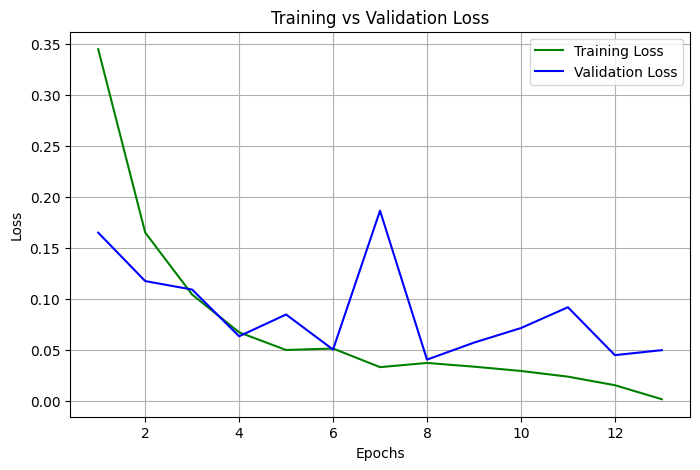

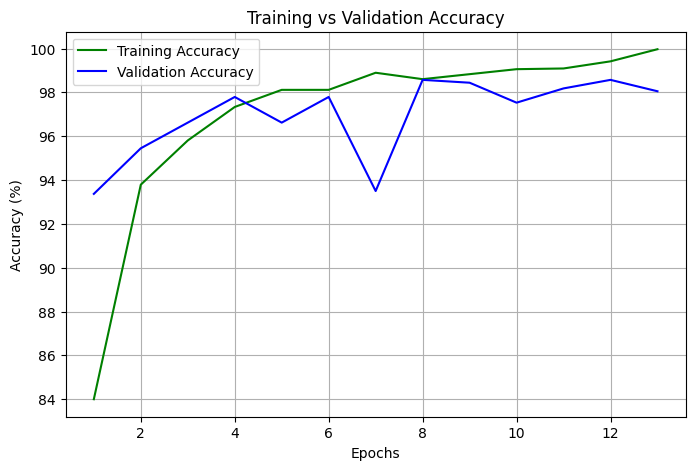


Final Confusion Matrix:
[[379  12]
 [  3 375]]

Confusion Matrix Values:
True Negative (TN): 379
False Positive (FP): 12
False Negative (FN): 3
True Positive (TP): 375

Performance Metrics:
Accuracy: 98.04941482444734
Precision: 0.9689922480620154
Recall: 0.9920634920634921
F1 Score: 0.9803921568627451
Sensitivity: 0.9920634920634921
Specificity: 0.969309462915601
ROC-AUC: 0.9806864774895466


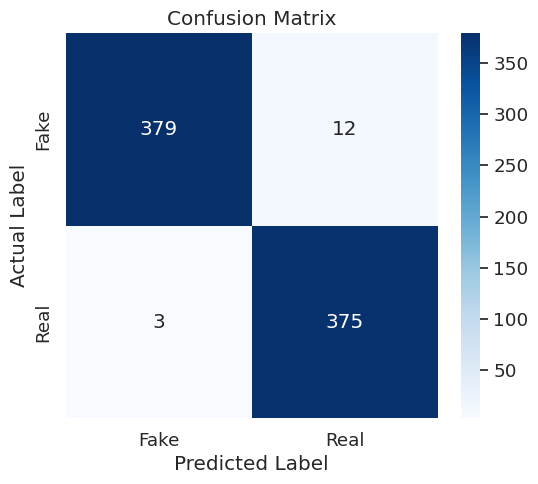

In [16]:
from sklearn.metrics import confusion_matrix
import torch.nn as nn

# ==========================================
# DEVICE
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ==========================================
# TRAIN SETTINGS
# ==========================================

lr = 1e-5

num_epochs = 20

patience = 5   # Early stopping


# ==========================================
# OPTIMIZER
# ==========================================

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=lr,

    weight_decay=1e-5

)


# ==========================================
# LOSS FUNCTION
# ==========================================

criterion = nn.CrossEntropyLoss().to(device)


# ==========================================
# LEARNING RATE SCHEDULER
# ==========================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode='min',

    patience=2,

    factor=0.5

)


# ==========================================
# STORAGE
# ==========================================

train_loss_avg = []

train_accuracy = []

test_loss_avg = []

test_accuracy = []

best_val_loss = float('inf')

early_stop_counter = 0


# ==========================================
# TRAIN LOOP
# ==========================================

for epoch in range(1, num_epochs+1):

    print(f"\nEpoch {epoch}/{num_epochs}")

    # TRAIN

    train_loss, train_acc = train_epoch(

        epoch,

        num_epochs,

        train_loader,

        model,

        criterion,

        optimizer

    )

    train_loss_avg.append(train_loss)

    train_accuracy.append(train_acc)


    # VALIDATE

    true, pred, val_loss, val_acc = test(

        epoch,

        model,

        valid_loader,

        criterion

    )

    test_loss_avg.append(val_loss)

    test_accuracy.append(val_acc)


    # Scheduler Step

    scheduler.step(val_loss)


    # ======================================
    # SAVE BEST MODEL
    # ======================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(

            model.state_dict(),

            "/kaggle/working/best_model.pt"

        )

        early_stop_counter = 0

        print("✅ Best model saved!")

    else:

        early_stop_counter += 1

        print(
            f"No improvement: {early_stop_counter}/{patience}"
        )


    # ======================================
    # EARLY STOPPING
    # ======================================

    if early_stop_counter >= patience:

        print("🛑 Early stopping triggered!")

        break


# ==========================================
# PLOT RESULTS
# ==========================================

plot_loss(

    train_loss_avg,

    test_loss_avg,

    len(train_loss_avg)

)

plot_accuracy(

    train_accuracy,

    test_accuracy,

    len(train_accuracy)

)


# ==========================================
# FINAL METRICS
# ==========================================

print("\nFinal Confusion Matrix:")

print(confusion_matrix(true, pred))

print_confusion_matrix(true, pred)